# RETAILPULSE
## Sales Performance & Customer Insights Analytics System

Data Analysis with Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/RETAILPULSE_sales_dataset.csv')

In [3]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Category,Sub_Category,Product,Region,City,Quantity,Sales,Discount,Profit,Payment_Mode
0,ORD-12771,2025-01-01,CUST-1744,Customer 1744,Office Supplies,Organizers,Desk Organizer,West,Mumbai,5,72743.00,0.15,12899.15,Net Banking
1,ORD-11411,2025-01-01,CUST-1349,Customer 1349,Appliances,Kitchen,Electric Kettle,West,Mumbai,4,47689.20,0.10,14463.19,Debit Card
2,ORD-12808,2025-01-01,CUST-1604,Customer 1604,Office Supplies,Binders,File Binder,West,Mumbai,5,93540.00,0.20,37272.04,Cash
3,ORD-14603,2025-01-01,CUST-1524,Customer 1524,Technology,Tablets,Tablet 10,East,Guwahati,5,70181.25,0.05,24030.66,Debit Card
4,ORD-10030,2025-01-01,CUST-1504,Customer 1504,Appliances,Kitchen,Electric Kettle,North,Jaipur,5,45780.00,0.00,17664.69,UPI


## 02. Dataset Overview

In [4]:
df.shape

(5000, 14)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Category',
       'Sub_Category', 'Product', 'Region', 'City', 'Quantity', 'Sales',
       'Discount', 'Profit', 'Payment_Mode'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       5000 non-null   object 
 1   Order_Date     5000 non-null   object 
 2   Customer_ID    5000 non-null   object 
 3   Customer_Name  5000 non-null   object 
 4   Category       5000 non-null   object 
 5   Sub_Category   5000 non-null   object 
 6   Product        5000 non-null   object 
 7   Region         5000 non-null   object 
 8   City           5000 non-null   object 
 9   Quantity       5000 non-null   int64  
 10  Sales          5000 non-null   float64
 11  Discount       5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment_Mode   5000 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 547.0+ KB


In [7]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Category,0
Sub_Category,0
Product,0
Region,0
City,0
Quantity,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [10]:
df.dtypes

,0
Order_ID,object
Order_Date,datetime64[ns]
Customer_ID,object
Customer_Name,object
Category,object
Sub_Category,object
Product,object
Region,object
City,object
Quantity,int64


In [11]:
df[['Quantity', 'Sales', 'Profit', 'Discount']].describe()

,Quantity,Sales,Profit,Discount
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.998400,45716.179540,12686.958000,0.109750
std,2.027022,36864.246201,11711.556332,0.071536
min,1.000000,245.600000,54.960000,0.000000
25%,2.000000,15447.075000,3737.995000,0.050000
50%,4.000000,36378.750000,8970.955000,0.100000
75%,6.000000,68183.250000,18225.092500,0.150000
max,7.000000,174783.000000,65954.150000,0.250000


In [12]:
(df['Sales'] < 0).sum(), (df['Quantity'] < 0).sum()

(np.int64(0), np.int64(0))

In [13]:
df['Discount'].min(), df['Discount'].max()

(0.0, 0.25)

In [14]:
df['Category'].value_counts()

,count
Category,
Technology,1295
Appliances,1256
Furniture,1240
Office Supplies,1209


In [15]:
df['Region'].value_counts()

,count
Region,
West,1301
North,1260
East,1229
South,1210


In [16]:
df['Payment_Mode'].value_counts()

,count
Payment_Mode,
Net Banking,1045
Debit Card,1018
UPI,996
Credit Card,983
Cash,958


In [17]:
df['Customer_ID'].nunique()

799

In [18]:
df['Order_Date'].min(), df['Order_Date'].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

## 04. Exploratory Data Analysis

In [19]:
df.describe()

,Order_Date,Quantity,Sales,Discount,Profit
count,5000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2025-06-30 10:52:53.760000,3.998400,45716.179540,0.109750,12686.958000
min,2025-01-01 00:00:00,1.000000,245.600000,0.000000,54.960000
25%,2025-04-01 00:00:00,2.000000,15447.075000,0.050000,3737.995000
50%,2025-07-03 12:00:00,4.000000,36378.750000,0.100000,8970.955000
75%,2025-09-27 00:00:00,6.000000,68183.250000,0.150000,18225.092500
max,2025-12-31 00:00:00,7.000000,174783.000000,0.250000,65954.150000
std,NaN,2.027022,36864.246201,0.071536,11711.556332


## 05. Sales Performance Analysis

In [20]:
total_revenue = df['Sales'].sum()
total_revenue

np.float64(228580897.70000002)

In [21]:
total_profit = df['Profit'].sum()
total_profit

np.float64(63434790.0)

In [22]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_revenue

,Sales
Category,
Technology,59869771.6
Appliances,57391052.6
Furniture,57327408.4
Office Supplies,53992665.1


In [23]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit

,Profit
Category,
Technology,16679898.18
Furniture,15969322.76
Appliances,15578091.78
Office Supplies,15207477.28


In [24]:
region_revenue = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_revenue

,Sales
Region,
West,57615833.40
South,57088986.75
East,57069388.25
North,56806689.30


In [25]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()
region_profit

,Profit
Region,
North,15615679.58
East,15685510.94
West,15983248.51
South,16150350.97


In [26]:
top_10_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)
top_10_products

,Sales
Product,
Toaster,8345148.40
File Binder,8125900.20
Tablet 10,7975806.20
Electric Kettle,7484353.65
Vacuum Cleaner,7386695.10
Document Tray,7345509.15
Desk Organizer,7298691.70
Blender,7282446.50
Ring Binder,7190250.05


In [27]:
top_10_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_10_customers

,Sales
Customer_Name,
Customer 1772,846455.65
Customer 1739,803485.65
Customer 1199,802617.95
Customer 1774,782194.35
Customer 1601,715279.30
Customer 1745,706342.40
Customer 1522,663120.90
Customer 1526,661461.30
Customer 1754,659447.40


In [28]:
df['Month'] = df['Order_Date'].dt.month_name()

In [29]:
monthly_sales = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
monthly_sales

,Sales
Month,
August,20758112.00
April,20372560.40
July,20345172.35
September,19993724.20
January,19915737.65
March,19520018.40
May,18849773.90
October,18293644.05
November,18253138.30


In [30]:
category_comparison = pd.DataFrame({
    'Total Revenue': category_revenue,
    'Total Profit': category_profit
})

category_comparison

,Total Revenue,Total Profit
Category,,
Appliances,57391052.6,15578091.78
Furniture,57327408.4,15969322.76
Office Supplies,53992665.1,15207477.28
Technology,59869771.6,16679898.18


## 06. Product & Category Analysis

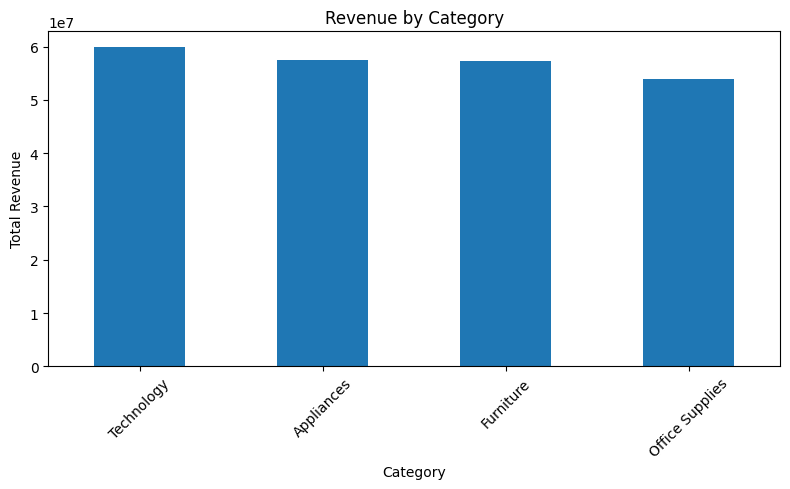

In [31]:
category_revenue.plot(kind='bar', figsize=(8, 5))

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

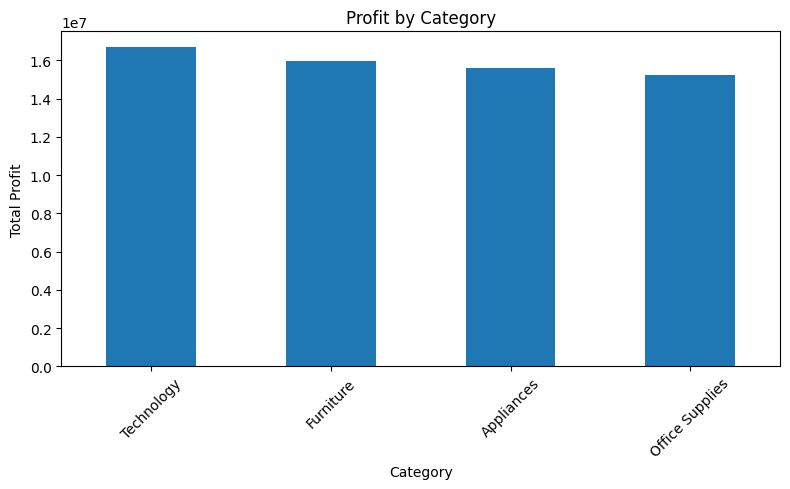

In [32]:
category_profit.plot(kind='bar', figsize=(8, 5))

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

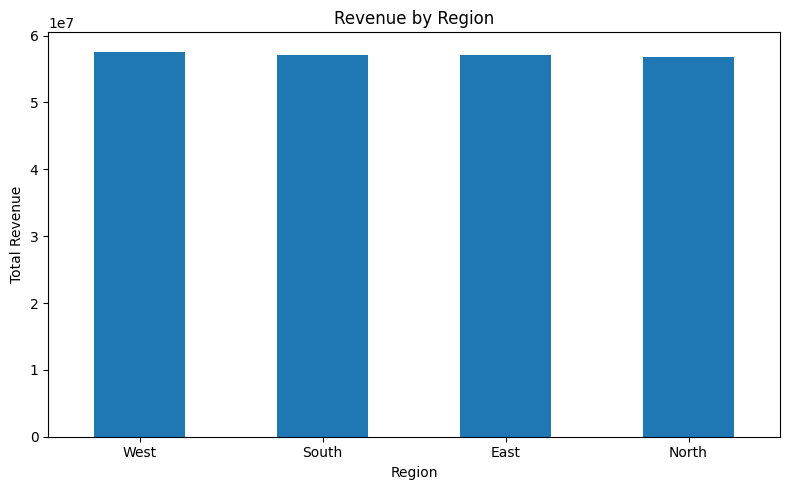

In [33]:
region_revenue.plot(kind='bar', figsize=(8, 5))

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

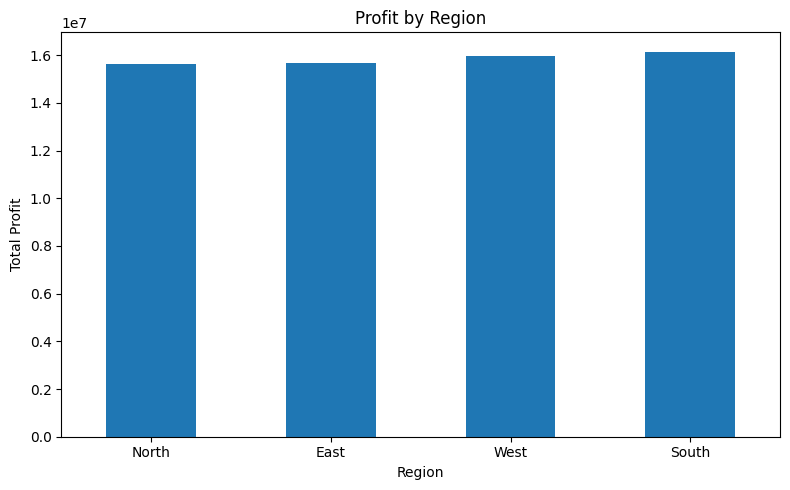

In [34]:
region_profit.plot(kind='bar', figsize=(8, 5))

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

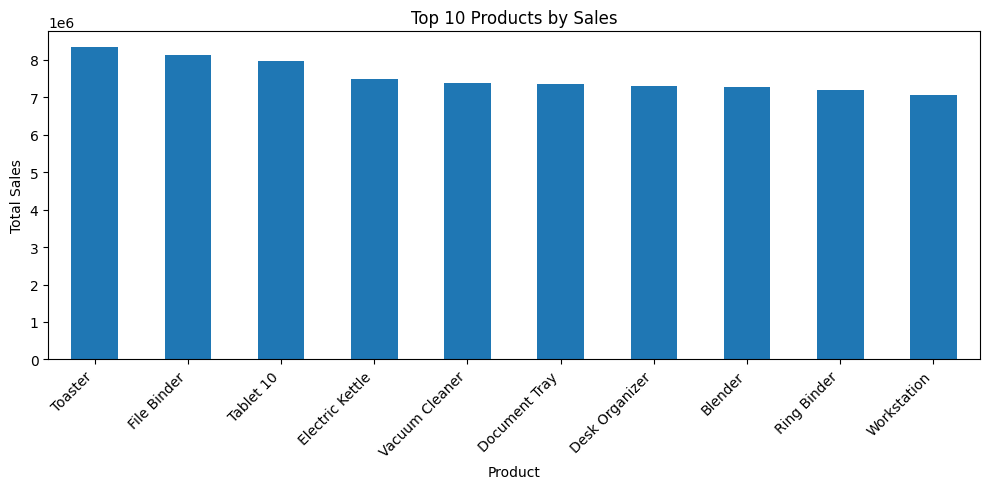

In [35]:
top_10_products.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

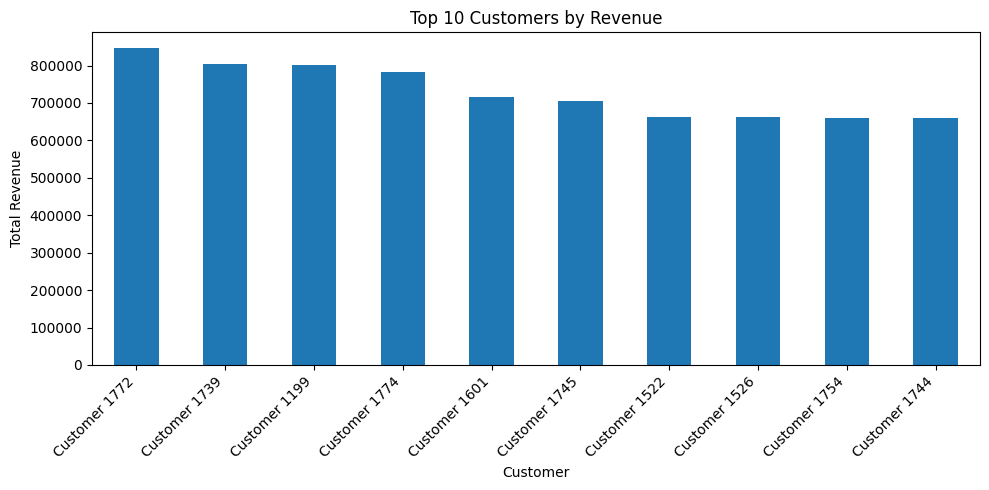

In [36]:
top_10_customers.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 09. Time-Series Analysis

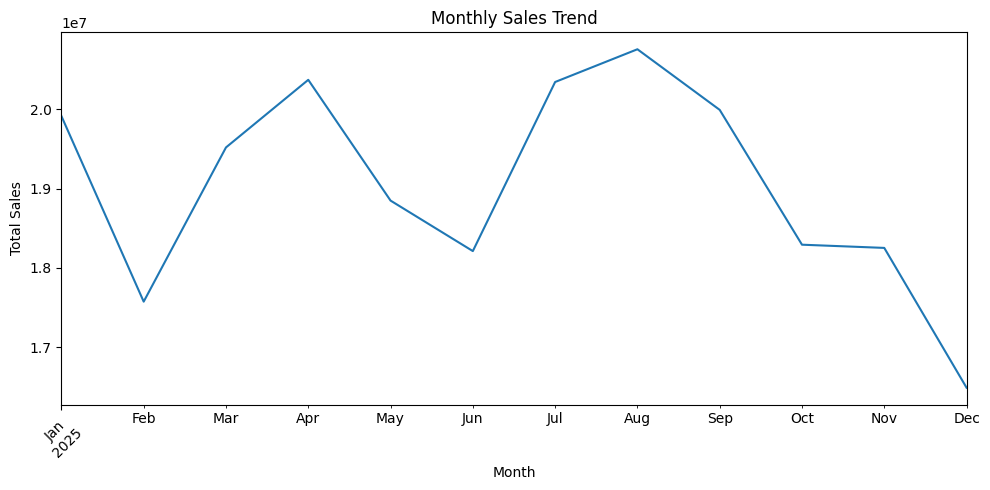

In [37]:
monthly_sales_time = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales_time.plot(kind='line', figsize=(10, 5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

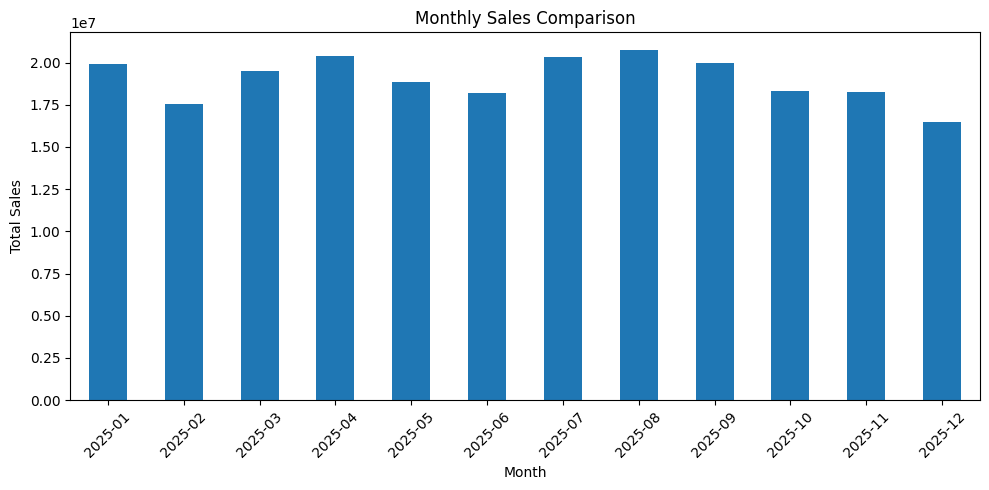

In [38]:
monthly_sales_time.plot(kind='bar', figsize=(10, 5))

plt.title('Monthly Sales Comparison')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Key Insights

In [39]:
print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Top Revenue Category:", category_revenue.index[0])
print("Top Profit Category:", category_profit.index[0])
print("Top Revenue Region:", region_revenue.index[0])
print("Weakest Profit Region:", region_profit.index[0])
print("Top Product:", top_10_products.index[0])
print("Top Customer:", top_10_customers.index[0])
print("Highest Sales Month:", monthly_sales_time.idxmax())

Total Revenue: 228580897.70000002
Total Profit: 63434790.0
Top Revenue Category: Technology
Top Profit Category: Technology
Top Revenue Region: West
Weakest Profit Region: North
Top Product: Toaster
Top Customer: Customer 1772
Highest Sales Month: 2025-08


### Finding 01 — Overall Business Performance

The business generated total revenue of ₹[your total revenue] and total profit of ₹[your total profit] during the analysis period.

### Finding 02 — Top Revenue Category

The category generating the highest total revenue is **[category name]**, with revenue of ₹[revenue amount].

### Finding 03 — Top Profit Category

The category generating the highest total profit is **[category name]**, with profit of ₹[profit amount].

### Finding 04 — Regional Performance

The region generating the highest total revenue is **[region name]**, with revenue of ₹[revenue amount].

### Finding 05 — Weakest Profit Region

The region with the lowest total profit is **[region name]**, with profit of ₹[profit amount].

### Finding 06 — Top Product

The product generating the highest total sales is **[product name]**, with sales of ₹[sales amount].

### Finding 07 — Top Customer

The customer contributing the highest revenue is **[customer name]**, with revenue of ₹[revenue amount].

### Finding 08 — Highest Sales Month

The month with the highest total sales is **[month]**, with sales of ₹[sales amount].

In [40]:
highest_revenue_category = category_revenue.idxmax()
highest_profit_category = category_profit.idxmax()

print("Highest Revenue Category:", highest_revenue_category)
print("Highest Profit Category:", highest_profit_category)
print("Same Category:", highest_revenue_category == highest_profit_category)

Highest Revenue Category: Technology
Highest Profit Category: Technology
Same Category: True


### Finding 09 — Revenue vs Profit Category

The category with the highest revenue is **[revenue category]**, while the category with the highest profit is **[profit category]**.

Therefore, the category with the highest revenue **[also has / does not have]** the highest profit.

## 10. Business Questions

### Question 1 — What is the total revenue generated?

**Answer:** The total revenue generated during the analysis period is **₹[total revenue]**.

### Question 2 — What is the total profit generated?

**Answer:** The total profit generated during the analysis period is **₹[total profit]**.

### Question 3 — Which category generates the most revenue?

**Answer:** The category generating the highest revenue is **[category name]**, with total revenue of **₹[revenue amount]**.

### Question 4 — Which category generates the most profit?

**Answer:** The category generating the highest profit is **[category name]**, with total profit of **₹[profit amount]**.

### Question 5 — Which region generates the most revenue?

**Answer:** The region generating the highest revenue is **[region name]**, with total revenue of **₹[revenue amount]**.

### Question 6 — Which region has the weakest profit performance?

**Answer:** The region with the lowest total profit is **[region name]**, with total profit of **₹[profit amount]**.

### Question 7 — What are the top 10 products by sales?

**Answer:** The top 10 products by total sales are shown below:

1. [Product 1]
2. [Product 2]
3. [Product 3]
4. [Product 4]
5. [Product 5]
6. [Product 6]
7. [Product 7]
8. [Product 8]
9. [Product 9]
10. [Product 10]

### Question 8 — Who are the top 10 customers by revenue?

**Answer:** The top 10 customers by total revenue are shown below:

1. [Customer 1]
2. [Customer 2]
3. [Customer 3]
4. [Customer 4]
5. [Customer 5]
6. [Customer 6]
7. [Customer 7]
8. [Customer 8]
9. [Customer 9]
10. [Customer 10]

### Question 9 — Which month has the highest sales?

**Answer:** The month with the highest total sales is **[month]**, with total sales of **₹[sales amount]**.

### Question 10 — Does the category with the highest sales also have the highest profit?

**Answer:** The category with the highest revenue is **[revenue category]**, while the category with the highest profit is **[profit category]**.

Therefore, the category with the highest sales **[also has / does not have]** the highest profit.

## 12. Recommendations

### Recommendation 01 — Focus on the Highest-Revenue Category

The business should continue to monitor and support the **[highest revenue category]** because it generates the highest total revenue. Management can review its product performance, customer demand, and sales trends to identify opportunities for further growth.

### Recommendation 02 — Improve the Weakest Profit Region

The business should review the performance of the **[weakest profit region]** because it has the lowest total profit. Management should examine pricing, discounts, product mix, and operating costs in this region to identify opportunities to improve profitability.

### Recommendation 03 — Strengthen the Top Profit Category

The business should continue monitoring the **[highest profit category]** because it generates the highest total profit. Management can review its products, pricing, and customer demand to identify opportunities for maintaining and improving profitability.

### Recommendation 04 — Focus on Top-Selling Products

The business should closely monitor the top-selling products and ensure that popular products remain available. Inventory planning and promotional strategies can be aligned with products that generate strong sales.

### Recommendation 05 — Retain High-Value Customers

The business should focus on retaining its highest-revenue customers through targeted offers, personalized communication, and customer relationship strategies.

### Recommendation 06 — Plan Around Sales Trends

The business should monitor monthly sales patterns and use periods of higher sales to improve inventory planning, staffing, and promotional activities.

## 13. Final Executive Summary

In [41]:
orders = df['Order_ID'].nunique()
customers = df['Customer_ID'].nunique()
average_order_value = total_revenue / orders
profit_margin = (total_profit / total_revenue) * 100

print("Total Sales:", total_revenue)
print("Total Profit:", total_profit)
print("Orders:", orders)
print("Customers:", customers)
print("Average Order Value:", average_order_value)
print("Profit Margin:", profit_margin)

Total Sales: 228580897.70000002
Total Profit: 63434790.0
Orders: 5000
Customers: 799
Average Order Value: 45716.179540000005
Profit Margin: 27.751570948529004


### Business Snapshot

- **Total Sales:** ₹[total sales]
- **Total Profit:** ₹[total profit]
- **Orders:** [number of orders]
- **Customers:** [number of customers]
- **Average Order Value:** ₹[average order value]
- **Profit Margin:** [profit margin]%

### Top Findings

1. **[Top revenue category]** generated the highest revenue.
2. **[Top profit category]** generated the highest profit.
3. **[Top revenue region]** generated the highest regional revenue.
4. **[Weakest profit region]** recorded the lowest total profit.
5. **[Top product]** was the highest-selling product.
6. **[Top customer]** generated the highest customer revenue.
7. **[Highest sales month]** recorded the highest monthly sales.

### Business Opportunities

The analysis highlights opportunities to strengthen high-performing categories and products, improve profitability in weaker regions, retain high-value customers, and use monthly sales patterns for better planning.

### Recommended Next Steps

1. Monitor category and product performance regularly.
2. Investigate the causes of weak regional profitability.
3. Develop retention strategies for high-value customers.
4. Use monthly sales trends for inventory and promotional planning.
5. Review pricing, discounts, and product mix to support profitability.

### Final Conclusion

The RETAILPULSE analysis provides a clear view of sales, profit, product, regional, customer, and time-based performance. The results can help management identify strong-performing areas, investigate weaker performance, and make data-driven decisions for future business growth.

## 01. Business Understanding

### Project Objective

The objective of this project is to analyze RETAILPULSE sales data to understand sales performance, profitability, product performance, regional performance, customer behavior, and monthly sales trends.

## 07. Regional Analysis

## 08. Customer Analysis

## 09. Time-Series Analysis

### Data Cleaning Summary

- Checked for missing values.
- Checked for duplicate records.
- Converted Order_Date to datetime format.
- Checked numeric data for negative Sales and Quantity values.
- Reviewed the Discount range.
- Confirmed the main categorical and numerical fields for analysis.

### Product Analysis Summary

Product and category performance were analyzed using total sales and total profit. The analysis also identified the top 10 products by sales to highlight the products contributing most strongly to overall revenue.

### Regional Analysis Summary

Regional performance was evaluated using total revenue and total profit. This analysis identifies the strongest revenue-generating region and the region with the lowest total profit.

### Customer Analysis Summary

Customer performance was analyzed by calculating total revenue generated by each customer. The top 10 customers were identified to highlight the highest-value customers in the dataset.

### Time-Series Analysis Summary

Monthly sales were analyzed to identify sales trends and determine which month generated the highest total sales.

01. Business Understanding
02. Dataset Overview
03. Data Cleaning
04. Exploratory Data Analysis
05. Sales Performance Analysis
06. Product & Category Analysis
07. Regional Analysis
08. Customer Analysis
09. Time-Series Analysis
10. Business Questions
11. Key Insights
12. Recommendations
13. Final Executive Summary

In [42]:
product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

top_20_percent_count = int(len(product_sales) * 0.20)

top_20_products = product_sales.head(top_20_percent_count)

top_20_revenue_share = (top_20_products.sum() / product_sales.sum()) * 100

print("Number of Products:", len(product_sales))
print("Top 20% Product Count:", top_20_percent_count)
print("Revenue Share of Top 20% Products:", top_20_revenue_share)

Number of Products: 40
Top 20% Product Count: 8
Revenue Share of Top 20% Products: 26.793381037631654


### Pareto Analysis

The top 20% of products generated approximately **[revenue share]%** of total product sales. This indicates how strongly sales are concentrated among the highest-performing products.

# RETAILPULSE — Visual Dashboard

This dashboard provides a visual summary of sales, profit, category, regional, product, and monthly performance.

In [43]:
print("RETAILPULSE DASHBOARD")
print("---------------------")
print("Total Sales:", total_revenue)
print("Total Profit:", total_profit)
print("Total Orders:", orders)
print("Total Customers:", customers)
print("Average Order Value:", average_order_value)
print("Profit Margin:", profit_margin)

RETAILPULSE DASHBOARD
---------------------
Total Sales: 228580897.70000002
Total Profit: 63434790.0
Total Orders: 5000
Total Customers: 799
Average Order Value: 45716.179540000005
Profit Margin: 27.751570948529004


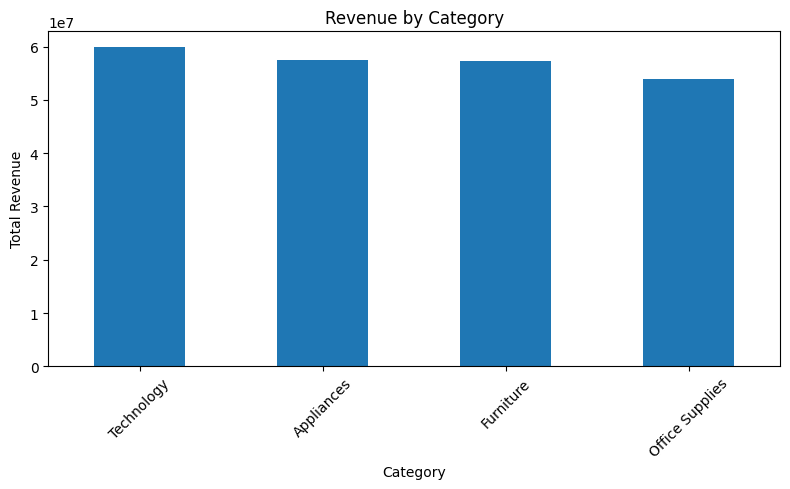

In [44]:
category_revenue.plot(kind='bar', figsize=(8, 5))

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

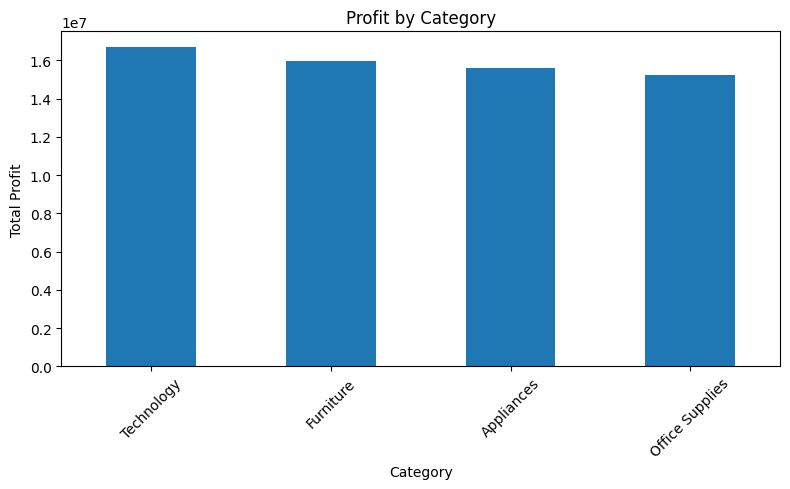

In [45]:
category_profit.plot(kind='bar', figsize=(8, 5))

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

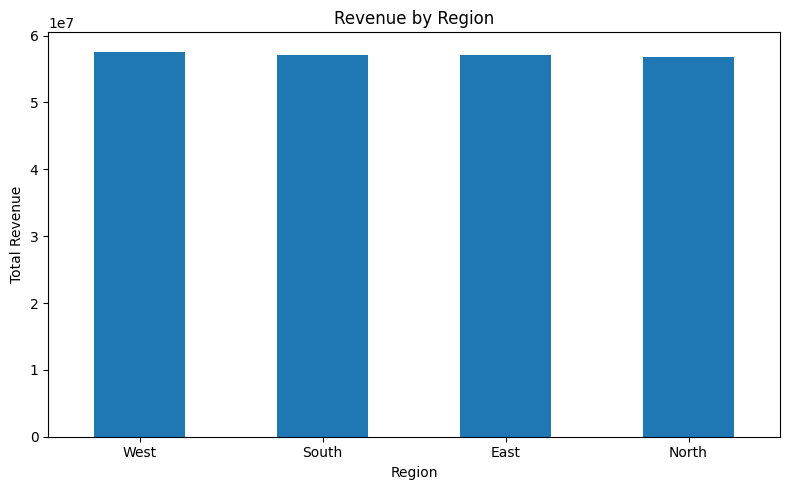

In [46]:
region_revenue.plot(kind='bar', figsize=(8, 5))

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

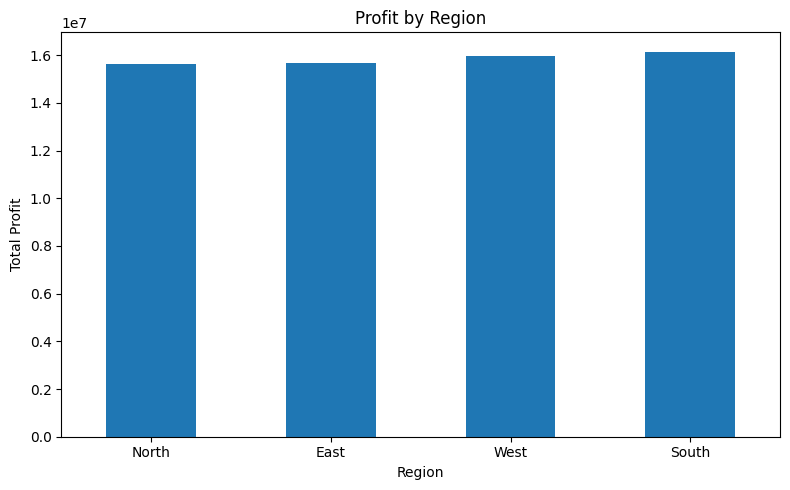

In [47]:
region_profit.plot(kind='bar', figsize=(8, 5))

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

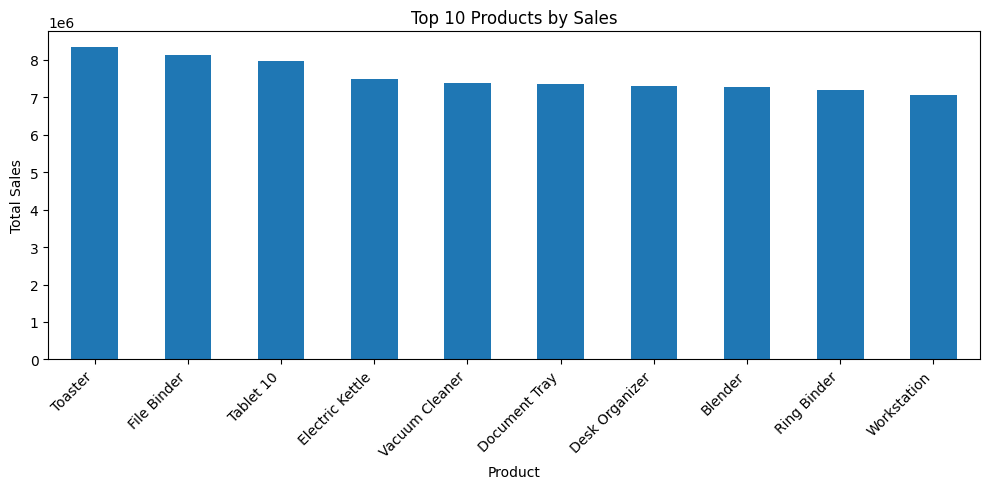

In [48]:
top_10_products.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

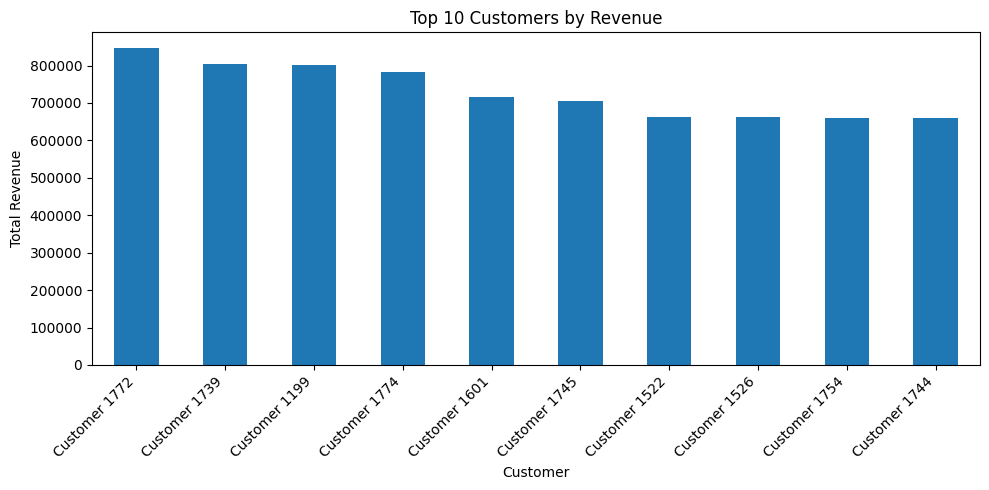

In [49]:
top_10_customers.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

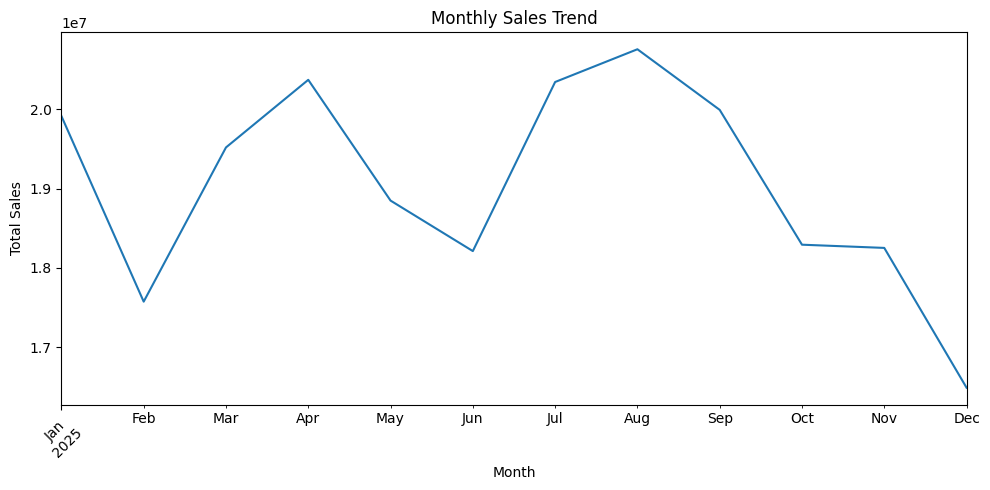

In [50]:
monthly_sales_time.plot(kind='line', figsize=(10, 5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Dashboard Insights

### Key Observations

- The highest-revenue category is **[category name]**.
- The highest-profit category is **[category name]**.
- The highest-revenue region is **[region name]**.
- The weakest-profit region is **[region name]**.
- The top-selling product is **[product name]**.
- The highest-revenue customer is **[customer name]**.
- The month with the highest sales is **[month]**.

### Dashboard Conclusion

The RETAILPULSE dashboard summarizes the major sales, profit, product, regional, customer, and monthly performance patterns identified in the analysis. It provides a visual overview that can help management quickly understand business performance and areas requiring further investigation.